In [1]:
import lhapdf
import pyhepmc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# initialization of variables
input_file = "/Users/ramos/mg5amcnlo/nuDIS_charged/Events/run_01/tag_1_pythia8_events.hepmc.gz"
n_events = None
n_mux = 9

pdf_name = "NNPDF23_lo_as_0130_qed"
pdf_set = lhapdf.getPDFSet(pdf_name)
pdf_size = pdf_set.size-1

In [3]:
def get_events(input_file_path):
    """ returns a list of events using pyhepmc """

    with pyhepmc.open(input_file_path, format="hepmc2") as file:
        events = list(file)
    return events

In [4]:
def read_events(kevents):
    """ 
    read events and returns two dataframes:
    events_record_df: with relevant parameters (weights, pt, etc) for all particles in the final state of each event
    events_info_df: with information about the event, such as weights and 9-point scale variations
    """
    
    events_record = []
    events_info = []
    for ievt, event in enumerate(kevents):
        weight = event.weights[0]
        for p in event.particles:
            # keep only final state particles
            if p.status != 1:
                continue
            pid = p.pid
            pN = p.momentum

            # saves information in dictionary format
            events_record.append({
                "event": ievt,
                "ID": pid,
                "weight": weight,
                "p_{T}": pN.pt(),
                "y": pN.rap()
                })
            
        # record weights and 9-point scale uncertainties for each event, using default dynamical scale
        # the variation on mux follows: w_mur_muf, (e.g. "w_05_10" means mur=0.5, muf=1.0)
        # the values are hardcoded, so be mindful when dealing with other hepmc files or mg5 versions
        # in this case, the weights follow: 0 = central, 1 = nominal weight, {mux variation}, {pdf variations}, resulting in 146 elements
        events_info.append({
            "event": ievt,
            "wgt_central": weight,
            "w_05_05": event.weights[2],
            "w_05_10": event.weights[7],
            "w_05_20": event.weights[12],
            "w_10_05": event.weights[17],
            "w_10_10": event.weights[1], # nominal value
            "w_10_20": event.weights[26],
            "w_20_05": event.weights[31],
            "w_20_10": event.weights[36],
            "w_20_20": event.weights[41]
            })
        
    events_record_df = pd.DataFrame(events_record)
    events_info_df = pd.DataFrame(events_info)
    
    return events_record_df, events_info_df
    

In [5]:
# auxiliary functions for plotting
def build_scale_hist(df,  observable, bins=20):

    n_evts = df["event"].max() + 1
    var_columns = [i for i in df.columns if i.startswith("w_")]

#     hist_nom, bin_edges = np.histogram(df[observable], bins=bins, weights=df["weight"]/n_evts)

    hist_mux_array = [None]*len(var_columns)

    for j, mux_name in enumerate(var_columns):
            hist_mux_array[j], _ = np.histogram(df[observable], weights=df[mux_name]/n_evts, bins=bins)

    # build max, min, central from 9-point envelope
    hist_mux_hix = np.maximum.reduce(hist_mux_array)
    hist_mux_lox = np.minimum.reduce(hist_mux_array)

    return hist_mux_lox, hist_mux_hix

In [6]:
def plot_particle_dist(particle_dict, observable, bins=20, show_uncertainty=True):
    import mplhep as mh
    import seaborn as sns

    fig, ax = plt.subplots(figsize=(8,6))

    mh.style.use("CMS")
    colors = {label : sns.color_palette('deep', n_colors=16)[i] for i,label in enumerate(particle_dict.keys())}    

    for label, df in particle_dict.items():

        hist_mu_lox, hist_mu_hix = build_scale_hist(df, observable,bins)

        # bin_center = 0.5*(bin_edges[1:] + bin_edges[:-1])
        n_evts = df["event"].max() + 1
        
        hist_mux_cen, tmp_bins, tmp_bars = ax.hist(df[observable], bins=bins, weights=df["weight"]/n_evts, 
                                                   histtype='step', color=colors[label], linewidth=2.0, label=label) 

        if show_uncertainty:

            ax.bar(x=tmp_bins[:-1], height=hist_mu_hix-hist_mu_lox, bottom=hist_mu_lox, width=np.diff(tmp_bins), 
                   align='edge', zorder=-1, color=colors[label], alpha=0.6)

    ax.set_yscale("log")
    ax.set_xlabel(r"$%s$ (GeV)" %(observable), loc="center")
    # ax.set_ylabel(r'$d\sigma/dp_T$',loc="center")
    ax.set_ylabel(r'$N$ (normalized)',loc="center")

    ax.legend()

    return fig, ax

In [7]:
events = get_events(input_file)
events_record_df, events_info_df = read_events(events)
print("Total cross-section: %.3f pb." %(events_info_df["wgt_central"].sum()/len(events_info_df["wgt_central"])))

Total cross-section: 5.326 pb.


In [8]:
events_record_df["ID"].unique()

array([ 2112,    22,    12,   211,  -211,  2212,    13,   -14,   321,
        -321,   130, -2112, -2212,    11,   -11,   -12,   -16,    16,
         -13])

In [9]:
def get_particle_df(pid):
    return (events_record_df[events_record_df["ID"] == pid].merge(events_info_df, on="event"))

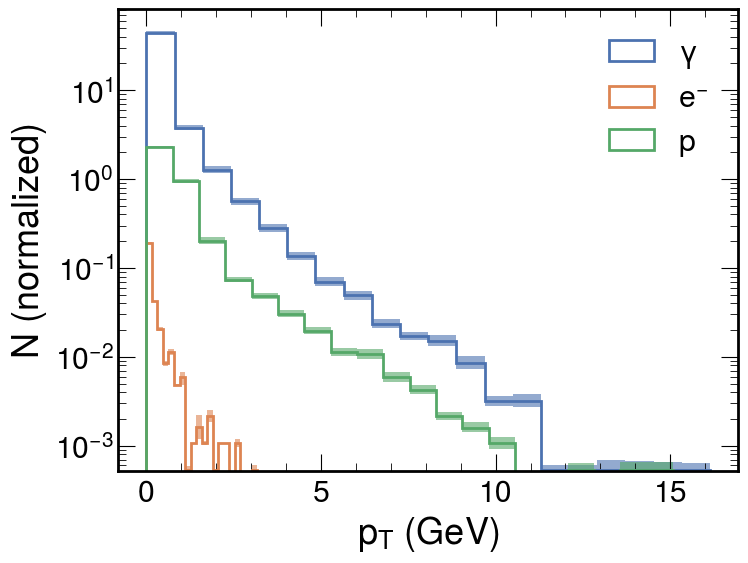

In [11]:
fig, ax = plot_particle_dist(particle_dict={r"$\gamma$": get_particle_df(22),
                                            r"$e^{-}$": get_particle_df(11),
                                            r"$p$": get_particle_df(2212)},
                             observable="p_{T}")
plt.show()

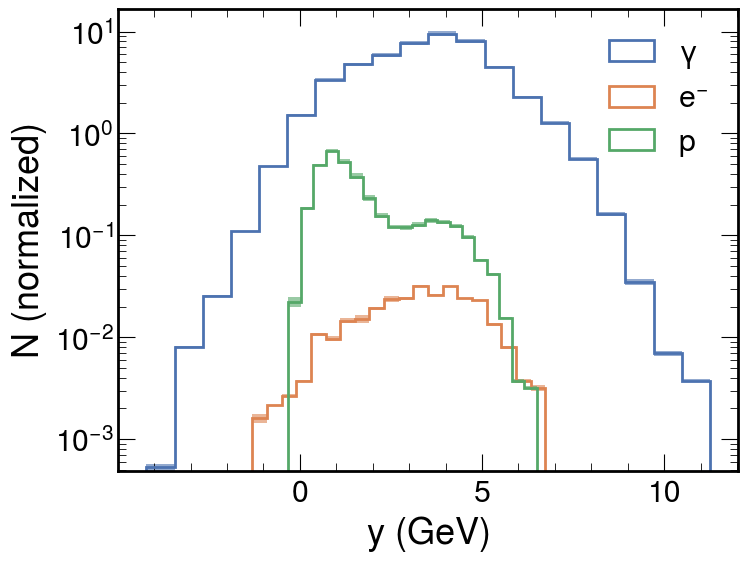

In [12]:
fig, ax = plot_particle_dist(particle_dict={r"$\gamma$": get_particle_df(22),
                                            r"$e^{-}$": get_particle_df(11),
                                            r"$p$": get_particle_df(2212)},
                             observable="y")
plt.show()